# Decorrelation Scale window analysis Testing  

**Purpose**: Code for testing the Autocorrelation and decorrelation scale functions on fake data

**Luke Colosi | lcolosi@ucsd.edu**

Force matplotlib plots to display directly within the output cell of the notebook: 

In [1]:
%matplotlib inline


Import python libraries


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import sys

# Set path to access python functions
sys.path.append('/Users/lukecolosi/Desktop/projects/graduate_research/Gille_lab/AirSeaCoupling/tools/')

#--- Luke's Python Functions ---# 
from lsf import detrend
from autocorr import compute_decor_scale_optimize, compute_autocorr_optimize, windowed_decorrelation_scale
from spectra import generate_powerlaw_data

Set plotting parameters

In [3]:
fontsize = 12

# Set font and fontsize
plt.rcParams.update({
    "font.size": fontsize,                          # Fontsize
    "text.usetex": True,                           # Use LaTeX for all text
    "font.family": "serif",                         # Optional: match LaTeX font
    "text.latex.preamble": r"\usepackage{amsmath}"  # Optional: load extra LaTeX packages
})

Create synthetic test data

In [4]:
# Set parameters for test data
np.random.seed(0)
N     = 3*365
dt    = 1.0              # Units: days
T     = 365/2            # Units: days
noise = 0              

# Create synthetic test data 
t = np.arange(N) * dt
data = np.sin(2 * np.pi * t / T) + noise * np.random.randn(N)

# Convert time in years
t_year = t * (1/365)

# Add some NaNs to test masking
#data[20:30] = np.nan
#t[200:210] = np.nan

Visualize data

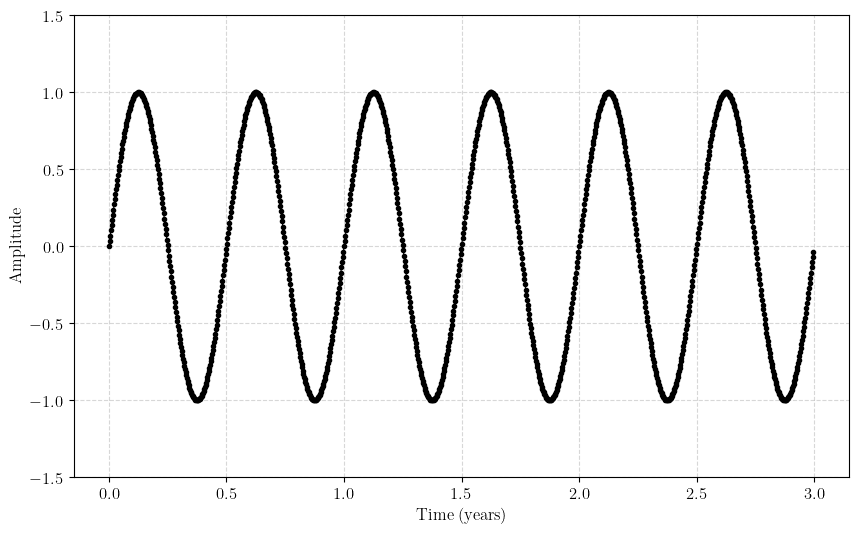

In [5]:
# Create figure
fig,ax = plt.subplots(figsize=(10,6))

# Plot data
ax.plot(t_year,data,'.-',lw=0.8, color='k')

# Set figure attributes
ax.set_xlabel('Time (years)')
ax.set_ylabel('Amplitude')
ax.set_ylim(-1.5, 1.5)
ax.grid(True,ls='--',alpha=0.5)

Compute decorrelation scalesas a function of duration

In [15]:
# Set window sizes (units: number of samples)
# min_window   = 365/12        
# max_window   = N // 2     # at least 3 windows fit
# n_windows    = 200
# wins         = np.linspace(min_window, max_window, n_windows)
# window_sizes = np.round(wins).astype(int)

# Set windowing parameters
min_window = 365/12            # Minimum window size of 1 month (in days)
max_divisor = N // min_window  # The largest n such that N/n >= 100

# Generate divisors (fractions of the total length): 2, 3, 4, ..., max_divisor
divisors = np.arange(2, max_divisor + 1)

# Calculate window sizes directly using integer division (//) to ensure they are integers
window_sizes = N // divisors

# Filter for range (if necessary) and remove duplicates
# (Duplicates can happen if N isn't perfectly divisible by many consecutive integers)
window_sizes = window_sizes[window_sizes >= min_window]

# Remove duplicates
window_sizes = np.unique(window_sizes)[::-1].astype(int)  # Unique and sorted largest to smallest
n_windows = len(window_sizes)  # Number of window lengths

# Set parameters
option_plot    = 0
option_text    = 0
scales         = window_sizes 
norm           = False 
overlap        = 0.5
return_windows = True
valid_frac     = 0.8

#-----------------------------------#
# STEP #1 - Preliminaries 
#-----------------------------------#

# Set nans to masked values and set total length of the time series
data = np.ma.masked_invalid(data)
t = np.ma.masked_invalid(t)
N = len(data)

# Validate overlap input
if not (0 <= overlap < 1):
    raise ValueError("overlap must be between 0 and 1 (fraction)")

# If no scales are provided, use powers of 2 up to the length of the time series
if scales is None:
    max_power = int(np.floor(np.log2(N)))
    scales = [2**k for k in range(3, max_power+1)] # e.g., [8,16,32,...]

# Ensure scales is a NumPy array
scales = np.array(scales)

# Compute the duration of each of the scales
duration = scales * dt

#-----------------------------------#
# STEP #1 - Compute decorrelation scale 
#-----------------------------------#

# Initialize arrays
Lt_av = np.ma.masked_all(len(scales))
Lt_stdm = np.ma.masked_all(len(scales))
window_decor_dict = {}

# Loop over scale
for i, L in enumerate(scales):

    if option_text == True: 
        print('%-------------%')
        print('Scale:' + str(L*dt))
        print('%-------------%')

    # Start indices for windows of length L
    step = max(1, int(L * (1 - overlap)))
    starts = np.arange(0, N - L + 1, step)

    if option_text == True: 
        print('Step Size:' + str(step*dt))
        print('Starting Indices:' + str(starts*dt))

    # Skip if the window size is too large for the series
    if len(starts) == 0:
        continue 

    # Store decorrelation scale of each window
    window_autocorr = []
    window_lag      = []
    window_decor    = []

    # Loop through windows
    for s in starts:

        # Extract segment/window
        segment = data[s:s+L]
        t_seg   = t[s:s+L]

        if option_plot == True: 
            # Plot the segment 
            fig,ax = plt.subplots(figsize=(8,6))
            ax.plot(t_seg,segment)
            ax.set_xlabel('Time (days)')
            ax.set_ylabel('Amplitude')
            ax.grid(True,ls='--',alpha=0.5)

        if option_text == True: 
            print('Length of Segement:' + str(segment.count()))

        # Require >= valid_frac fraction of valid data
        if (segment.count() >= valid_frac * L) and (t_seg.count() >= valid_frac * L):

            # Detrend window 
            segment_dt = detrend(segment,t_seg,mean=0) # segment - np.nanmean(segment) 

            # Compute autocorrelation function
            autocorr, _, _, _, lag, _ = compute_autocorr_optimize(segment_dt, t_seg, len(segment), 'biased', norm)

            # Compute the decorrelation scale
            seg_decor = compute_decor_scale_optimize(autocorr,lag,dt,'unbiased',norm)

            # Save the autocorrelation and decorrelation scales 
            window_autocorr.append(autocorr)
            window_lag.append(lag)
            window_decor.append(seg_decor)

    # Skip if no valid windows
    if len(window_decor) == 0:
        continue

    # Store per-window decorrelation scales
    window_decor_dict[L] = window_decor

    # Convert window_autocor from a list to an array
    window_autocorr = np.array(window_autocorr)
    window_lag = np.array(window_lag)

    # Average autocorrelation function across all windows for this scale 
    window_autocorr_av = np.nanmean(window_autocorr,axis=0)
    window_lag_av = np.nanmean(window_lag,axis=0)

    # Compute the standard deviation and the number of samples 
    window_autocorr_std = np.nanstd(window_autocorr, axis=0, ddof=1)
    window_autocorr_n   = np.count_nonzero(~np.isnan(window_autocorr), axis=0)

    # Compute the standard error of the mean (assuming that each data point is an independent observations)
    window_autocorr_stdm   = window_autocorr_std/np.sqrt(window_autocorr_n)

    # Skip if averaged autocorr is all NaN
    if np.all(np.isnan(window_autocorr_av)):
        continue

    # Compute average decorrelation scale
    window_decor_av = compute_decor_scale_optimize(
        window_autocorr_av, window_lag_av, dt, 'biased', norm
    )

    # Estimate the decorrelation scale's uncertainty by perturbing the autocorrelation function by 1 standard deviation
    window_decor_ustd = compute_decor_scale_optimize(window_autocorr_av + window_autocorr_stdm, 
                                            window_lag_av ,dt,'unbiased',norm)
    window_decor_lstd = compute_decor_scale_optimize(window_autocorr_av - window_autocorr_stdm, 
                                            window_lag_av ,dt,'unbiased',norm)

    # Compute the average standard error 
    std_upper = window_decor_ustd - window_decor_av
    std_lower = abs(window_decor_lstd - window_decor_av)
    window_decor_stdm  = np.mean([std_upper, std_lower])

    # Save the decorrelation scale
    Lt_av[i] = window_decor_av 
    Lt_stdm[i] = window_decor_stdm


Plot results

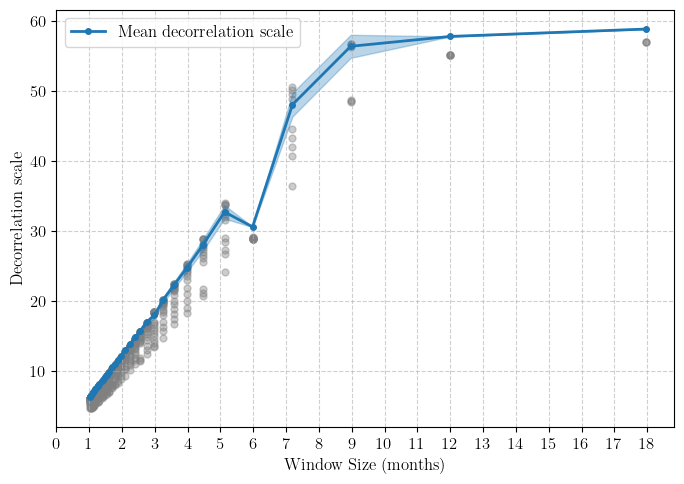

In [16]:
# --- Plot results ---
fig,ax = plt.subplots(figsize=(7,5))

# Plot per-window values as scatter
for L, vals in window_decor_dict.items():
    ax.scatter([L*dt*(1/30.44)]*len(vals), vals, color='gray', alpha=0.4, s=25, label='_nolegend_')

# Plot average decorrelation scale
ax.plot(scales*dt*(1/30.44), Lt_av, 'o-', color='tab:blue', lw=2, label='Mean decorrelation scale', markersize=4)

# Plot standard error of the mean 
ax.fill_between(scales*dt*(1/30.44), Lt_av - Lt_stdm, Lt_av + Lt_stdm, alpha = 0.3, color='tab:blue')

# Labels & formatting
ax.set_xlabel("Window Size (months)")
ax.set_ylabel("Decorrelation scale ")
ax.set_xticks(np.arange(0,19))
ax.grid(True, which='both', ls='--', alpha=0.6)
ax.legend()

# Display figure
plt.tight_layout()
plt.show()

Now test with three frequencies

Create synthetic test data

In [30]:
# Set parameters for test data
rng = np.random.default_rng(42)
N     = 3*365
dt    = 1.0                    # Units: days
T     = [365/2, 365/10, 365/30]  # Units: days
phase = rng.uniform(0, 2*np.pi, size=3)
noise = 0              

# Create synthetic test data 
t = np.arange(N) * dt
data = np.sin(2 * np.pi * t / T[0] + phase[0]) + np.sin(2 * np.pi * t / T[1] + phase[1]) + np.sin(2 * np.pi * t / T[2] + phase[2]) + noise * np.random.randn(N)

# Convert time in years
t_year = t * (1/365)

# Add some NaNs to test masking
#data[20:30] = np.nan
#t[200:210] = np.nan

Visualize data

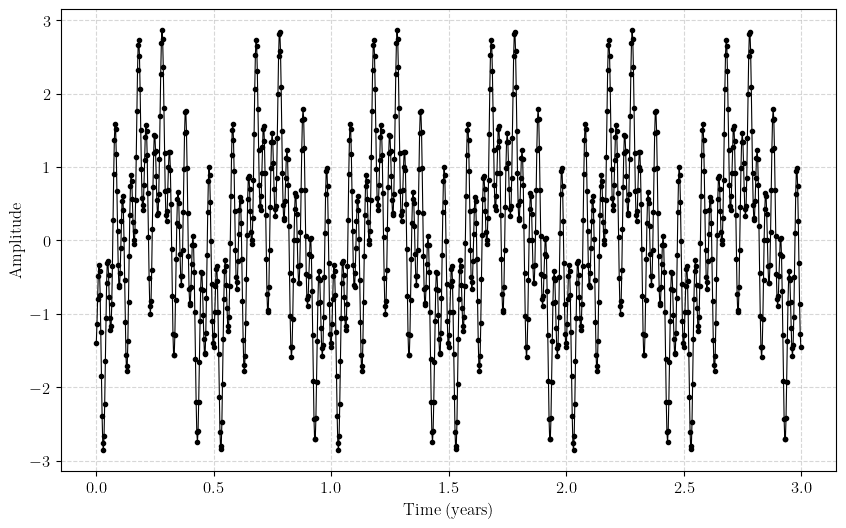

In [31]:
# Create figure
fig,ax = plt.subplots(figsize=(10,6))

# Plot data
ax.plot(t_year,data,'.-',lw=0.8, color='k')

# Set figure attributes
ax.set_xlabel('Time (years)')
ax.set_ylabel('Amplitude')
#ax.set_ylim(-1.5, 1.5)
ax.grid(True,ls='--',alpha=0.5)

Compute decorrelation scalesas a function of duration

In [32]:
# # Set window sizes (units: number of samples)
# min_window   = 365/12        
# max_window   = N // 2     # at least 3 windows fit
# n_windows    = 200
# wins         = np.linspace(min_window, max_window, n_windows)
# window_sizes = np.round(wins).astype(int)

# Set windowing parameters
min_window = 365/12            # Minimum window size of 1 month (in days)
max_divisor = N // min_window  # The largest n such that N/n >= 100

# Generate divisors (fractions of the total length): 2, 3, 4, ..., max_divisor
divisors = np.arange(2, max_divisor + 1)

# Calculate window sizes directly using integer division (//) to ensure they are integers
window_sizes = N // divisors

# Filter for range (if necessary) and remove duplicates
# (Duplicates can happen if N isn't perfectly divisible by many consecutive integers)
window_sizes = window_sizes[window_sizes >= min_window]

# Remove duplicates
window_sizes = np.unique(window_sizes)[::-1].astype(int)  # Unique and sorted largest to smallest
n_windows = len(window_sizes)  # Number of window lengths

# Set parameters
option_plot    = 0
option_text    = 0
scales         = window_sizes #[91, 182, 365]
norm           = False 
overlap        = 0.5
return_windows = True
valid_frac     = 0.8

#-----------------------------------#
# STEP #1 - Preliminaries 
#-----------------------------------#

# Set nans to masked values and set total length of the time series
data = np.ma.masked_invalid(data)
t = np.ma.masked_invalid(t)
N = len(data)

# Validate overlap input
if not (0 <= overlap < 1):
    raise ValueError("overlap must be between 0 and 1 (fraction)")

# If no scales are provided, use powers of 2 up to the length of the time series
if scales is None:
    max_power = int(np.floor(np.log2(N)))
    scales = [2**k for k in range(3, max_power+1)] # e.g., [8,16,32,...]

# Ensure scales is a NumPy array
scales = np.array(scales)

# Compute the duration of each of the scales
duration = scales * dt

#-----------------------------------#
# STEP #1 - Compute decorrelation scale 
#-----------------------------------#

# Initialize arrays
Lt_av = np.ma.masked_all(len(scales))
Lt_stdm = np.ma.masked_all(len(scales))
window_decor_dict = {}

# Loop over scale
for i, L in enumerate(scales):

    if option_text == True: 
        print('%-------------%')
        print('Scale:' + str(L*dt))
        print('%-------------%')

    # Start indices for windows of length L
    step = max(1, int(L * (1 - overlap)))
    starts = np.arange(0, N - L + 1, step)

    if option_text == True: 
        print('Step Size:' + str(step*dt))
        print('Starting Indices:' + str(starts*dt))

    # Skip if the window size is too large for the series
    if len(starts) == 0:
        continue 

    # Store decorrelation scale of each window
    window_autocorr = []
    window_lag      = []
    window_decor    = []

    # Loop through windows
    for s in starts:

        # Extract segment/window
        segment = data[s:s+L]
        t_seg   = t[s:s+L]

        if option_plot == True: 
            # Plot the segment 
            fig,ax = plt.subplots(figsize=(8,6))
            ax.plot(t_seg,segment)
            ax.set_xlabel('Time (days)')
            ax.set_ylabel('Amplitude')
            ax.grid(True,ls='--',alpha=0.5)

        if option_text == True: 
            print('Length of Segement:' + str(segment.count()))

        # Require >= valid_frac fraction of valid data
        if (segment.count() >= valid_frac * L) and (t_seg.count() >= valid_frac * L):

            # Detrend window 
            segment_dt = detrend(segment,t_seg,mean=0) # segment - np.nanmean(segment) 

            # Compute autocorrelation function
            autocorr, _, _, _, lag, _ = compute_autocorr_optimize(segment_dt, t_seg, len(segment), 'biased', norm)

            # Compute the decorrelation scale
            seg_decor = compute_decor_scale_optimize(autocorr,lag,dt,'unbiased',norm)

            # Save the autocorrelation and decorrelation scales 
            window_autocorr.append(autocorr)
            window_lag.append(lag)
            window_decor.append(seg_decor)

    # Skip if no valid windows
    if len(window_decor) == 0:
        continue

    # Store per-window decorrelation scales
    window_decor_dict[L] = window_decor

    # Convert window_autocor from a list to an array
    window_autocorr = np.array(window_autocorr)
    window_lag = np.array(window_lag)

    # Average autocorrelation function across all windows for this scale 
    window_autocorr_av = np.nanmean(window_autocorr,axis=0)
    window_lag_av = np.nanmean(window_lag,axis=0)

    # Compute the standard deviation and the number of samples 
    window_autocorr_std = np.nanstd(window_autocorr, axis=0, ddof=1)
    window_autocorr_n   = np.count_nonzero(~np.isnan(window_autocorr), axis=0)

    # Compute the standard error of the mean (assuming that each data point is an independent observations)
    window_autocorr_stdm   = window_autocorr_std/np.sqrt(window_autocorr_n)

    # Skip if averaged autocorr is all NaN
    if np.all(np.isnan(window_autocorr_av)):
        continue

    # Compute average decorrelation scale
    window_decor_av = compute_decor_scale_optimize(
        window_autocorr_av, window_lag_av, dt, 'biased', norm
    )

    # Estimate the decorrelation scale's uncertainty by perturbing the autocorrelation function by 1 standard deviation
    window_decor_ustd = compute_decor_scale_optimize(window_autocorr_av + window_autocorr_stdm, 
                                            window_lag_av ,dt,'unbiased',norm)
    window_decor_lstd = compute_decor_scale_optimize(window_autocorr_av - window_autocorr_stdm, 
                                            window_lag_av ,dt,'unbiased',norm)

    # Compute the average standard error 
    std_upper = window_decor_ustd - window_decor_av
    std_lower = abs(window_decor_lstd - window_decor_av)
    window_decor_stdm  = np.mean([std_upper, std_lower])

    # Save the decorrelation scale
    Lt_av[i] = window_decor_av 
    Lt_stdm[i] = window_decor_stdm


Plot results

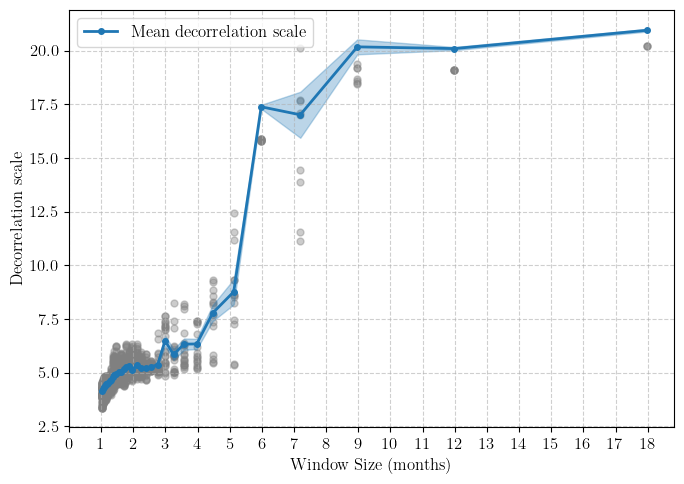

In [33]:
# --- Plot results ---
fig,ax = plt.subplots(figsize=(7,5))

# Plot per-window values as scatter
for L, vals in window_decor_dict.items():
    ax.scatter([L*dt*(1/30.44)]*len(vals), vals, color='gray', alpha=0.4, s=25, label='_nolegend_')

# Plot average decorrelation scale
ax.plot(scales*dt*(1/30.44), Lt_av, 'o-', color='tab:blue', lw=2, label='Mean decorrelation scale', markersize=4)

# Plot standard error of the mean 
ax.fill_between(scales*dt*(1/30.44), Lt_av - Lt_stdm, Lt_av + Lt_stdm, alpha = 0.3, color='tab:blue')

# Labels & formatting
ax.set_xlabel("Window Size (months)")
ax.set_ylabel("Decorrelation scale ")
ax.set_xticks(np.arange(0,19))
ax.grid(True, which='both', ls='--', alpha=0.6)
ax.legend()

# Display figure
plt.tight_layout()
plt.show()

Now test with power law data

In [29]:
# Set parameters
alpha = 2 
state = 42
N     = 2*365
dt    = 1.0              # Units: days

# Generate fake data 
t, data, f, psd = generate_powerlaw_data(N=N, alpha=alpha, random_state=state, dt=dt)

Plot data

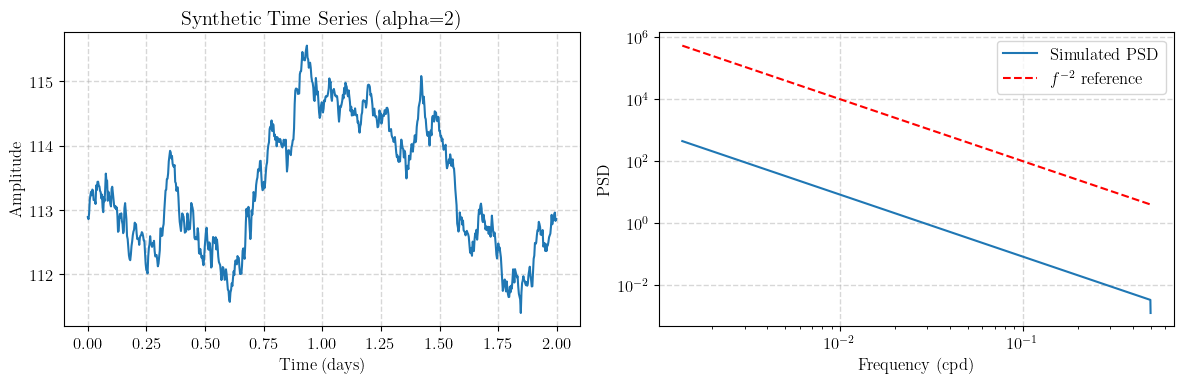

In [30]:
# Create figure
fig,axes = plt.subplots(1,2,figsize=(12,4))
ax1, ax2 = axes.flatten()

#--- Subplot 1 ---# 
ax1.plot(t*(1/365), data, color='tab:blue')

# Set axis attributes
ax1.set_title('Synthetic Time Series (alpha=' + str(alpha) + ')')
ax1.set_xlabel("Time (days)")
ax1.set_ylabel("Amplitude")
ax1.grid(ls='--',lw=1.0,alpha=0.5)

#--- Subplot 1 ---# 
ax2.loglog(f[1:], psd[1:], color='tab:blue', label="Simulated PSD")
plt.loglog(f[1:], f[1:]**(-alpha), 'r--', label=r"$f^{-" + str(alpha) + r"}$ reference")

# Set axis attributes
ax2.set_xlabel("Frequency (cpd)")
ax2.set_ylabel("PSD")
ax2.legend()
ax2.grid(ls='--',lw=1.0,alpha=0.5)

# Display figure
plt.tight_layout()
plt.show()

Compute decorrelation scales

In [32]:
# Set window sizes (units: number of samples)
min_window   = 365/12        
max_window   = N // 2     # at least 3 windows fit
n_windows    = 200
wins         = np.linspace(min_window, max_window, n_windows)
window_sizes = np.round(wins).astype(int)

# Set parameters
option_plot    = 0
option_text    = 0
scales         = window_sizes #[91, 182, 365]
norm           = False 
overlap        = 0.5
return_windows = True
valid_frac     = 0.8

#-----------------------------------#
# STEP #1 - Preliminaries 
#-----------------------------------#

# Set nans to masked values and set total length of the time series
data = np.ma.masked_invalid(data)
t = np.ma.masked_invalid(t)
N = len(data)

# Validate overlap input
if not (0 <= overlap < 1):
    raise ValueError("overlap must be between 0 and 1 (fraction)")

# If no scales are provided, use powers of 2 up to the length of the time series
if scales is None:
    max_power = int(np.floor(np.log2(N)))
    scales = [2**k for k in range(3, max_power+1)] # e.g., [8,16,32,...]

# Ensure scales is a NumPy array
scales = np.array(scales)

# Compute the duration of each of the scales
duration = scales * dt

#-----------------------------------#
# STEP #1 - Compute decorrelation scale 
#-----------------------------------#

# Detrend data 
data_dt = detrend(data,t,mean=0)

# Initialize arrays
Lt_av = np.ma.masked_all(len(scales))
Lt_stdm = np.ma.masked_all(len(scales))
window_decor_dict = {}

# Loop over scale
for i, L in enumerate(scales):

    if option_text == True: 
        print('%-------------%')
        print('Scale:' + str(L*dt))
        print('%-------------%')

    # Start indices for windows of length L
    step = max(1, int(L * (1 - overlap)))
    starts = np.arange(0, N - L + 1, step)

    if option_text == True: 
        print('Step Size:' + str(step*dt))
        print('Starting Indices:' + str(starts*dt))

    # Skip if the window size is too large for the series
    if len(starts) == 0:
        continue 

    # Store decorrelation scale of each window
    window_autocorr = []
    window_lag      = []
    window_decor    = []

    # Loop through windows
    for s in starts:

        # Extract segment/window
        segment = data[s:s+L]
        t_seg   = t[s:s+L]

        if option_plot == True: 
            # Plot the segment 
            fig,ax = plt.subplots(figsize=(8,6))
            ax.plot(t_seg,segment)
            ax.set_xlabel('Time (days)')
            ax.set_ylabel('Amplitude')
            ax.grid(True,ls='--',alpha=0.5)

        if option_text == True: 
            print('Length of Segement:' + str(segment.count()))

        # Require >= valid_frac fraction of valid data
        if (segment.count() >= valid_frac * L) and (t_seg.count() >= valid_frac * L):

            # Detrend window 
            segment_dt = segment - np.mean(segment) # detrend(segment,t_seg,mean=0)

            # Compute autocorrelation function
            autocorr, _, _, _, lag, _ = compute_autocorr_optimize(segment_dt, t_seg, len(segment), 'biased', norm)

            # Compute the decorrelation scale
            seg_decor = compute_decor_scale_optimize(autocorr,lag,dt,'unbiased',norm)

            # Save the autocorrelation and decorrelation scales 
            window_autocorr.append(autocorr)
            window_lag.append(lag)
            window_decor.append(seg_decor)

    # Skip if no valid windows
    if len(window_decor) == 0:
        continue

    # Store per-window decorrelation scales
    window_decor_dict[L] = window_decor

    # Convert window_autocor from a list to an array
    window_autocorr = np.array(window_autocorr)
    window_lag = np.array(window_lag)

    # Average autocorrelation function across all windows for this scale 
    window_autocorr_av = np.nanmean(window_autocorr,axis=0)
    window_lag_av = np.nanmean(window_lag,axis=0)

    # Compute the standard deviation and the number of samples 
    window_autocorr_std = np.nanstd(window_autocorr, axis=0, ddof=1)
    window_autocorr_n   = np.count_nonzero(~np.isnan(window_autocorr), axis=0)

    # Compute the standard error of the mean (assuming that each data point is an independent observations)
    window_autocorr_stdm   = window_autocorr_std/np.sqrt(window_autocorr_n)

    # Skip if averaged autocorr is all NaN
    if np.all(np.isnan(window_autocorr_av)):
        continue

    # Compute average decorrelation scale
    window_decor_av = compute_decor_scale_optimize(
        window_autocorr_av, window_lag_av, dt, 'biased', norm
    )

    # Estimate the decorrelation scale's uncertainty by perturbing the autocorrelation function by 1 standard deviation
    window_decor_ustd = compute_decor_scale_optimize(window_autocorr_av + window_autocorr_stdm, 
                                            window_lag_av ,dt,'unbiased',norm)
    window_decor_lstd = compute_decor_scale_optimize(window_autocorr_av - window_autocorr_stdm, 
                                            window_lag_av ,dt,'unbiased',norm)

    # Compute the average standard error 
    std_upper = window_decor_ustd - window_decor_av
    std_lower = abs(window_decor_lstd - window_decor_av)
    window_decor_stdm  = np.mean([std_upper, std_lower])

    # Save the decorrelation scale
    Lt_av[i] = window_decor_av 
    Lt_stdm[i] = window_decor_stdm

Plot results

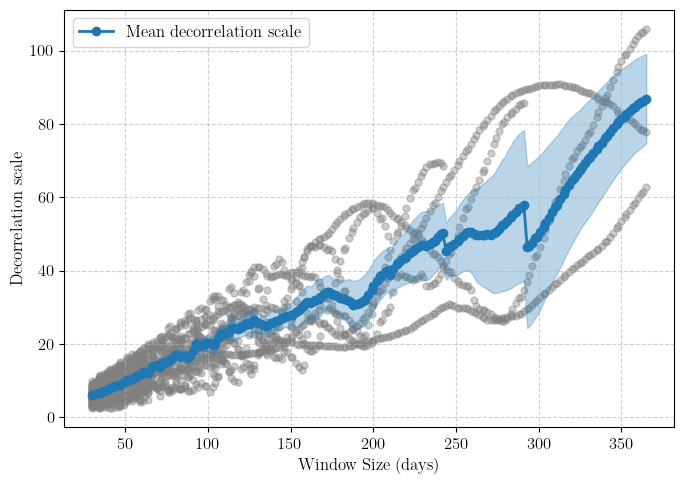

In [34]:
# --- Plot results ---
fig,ax = plt.subplots(figsize=(7,5))

# Plot per-window values as scatter
for L, vals in window_decor_dict.items():
    ax.scatter([L*dt]*len(vals), vals, color='gray', alpha=0.4, s=25, label='_nolegend_')

# Plot average decorrelation scale
ax.plot(scales*dt, Lt_av, 'o-', color='tab:blue', lw=2, label='Mean decorrelation scale')

# Plot standard error of the mean 
ax.fill_between(scales*dt, Lt_av - Lt_stdm, Lt_av + Lt_stdm, alpha = 0.3, color='tab:blue')

# Labels & formatting
ax.set_xlabel("Window Size (days)")
ax.set_ylabel("Decorrelation scale ")
ax.grid(True, which='both', ls='--', alpha=0.6)
ax.legend()

# Display figure
plt.tight_layout()
plt.show()

## Development Code

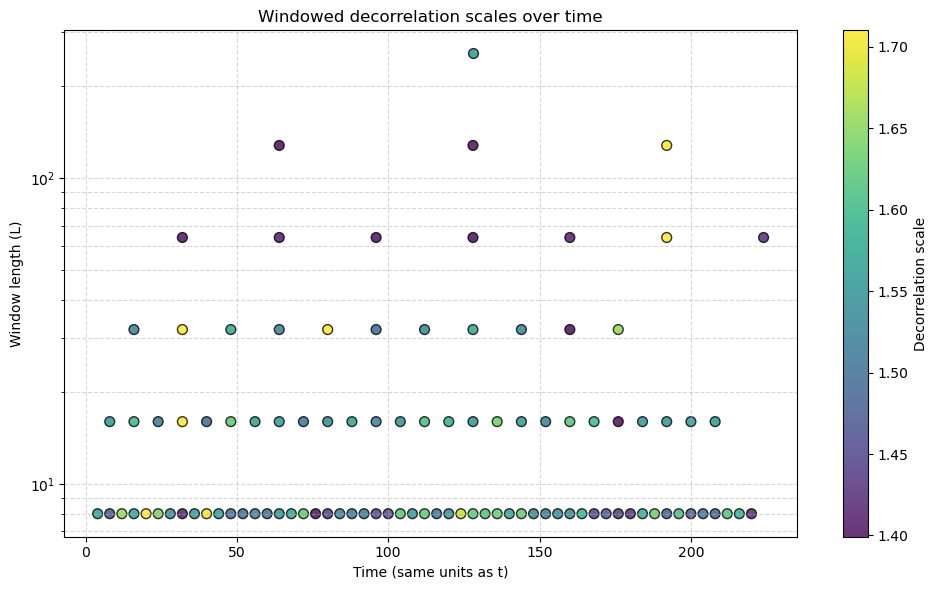

In [22]:
plt.figure(figsize=(10,6))

all_vals = []  # for setting color limits

for i, (L, vals) in enumerate(window_dict.items()):
    # Compute window centers in time (in samples)
    step = max(1, int(L * (1 - 0.5)))  # overlap=0.5
    starts = np.arange(0, len(data) - L + 1, step)
    centers = starts + L//2

    # Align lengths if needed
    n_valid = min(len(vals), len(centers))
    x = centers[:n_valid] * dt
    y = np.full_like(x, L)
    c = vals[:n_valid]

    all_vals.extend(c)
    # Keep a reference to the scatter for colorbar
    sc = plt.scatter(x, y, c=c, cmap='viridis', s=50, edgecolor='k', alpha=0.8)

# Colorbar for decorrelation scale
cbar = plt.colorbar(sc)
cbar.set_label('Decorrelation scale')

# Labels & formatting
plt.xlabel("Time (same units as t)")
plt.ylabel("Window length (L)")
plt.yscale('log')
plt.title("Windowed decorrelation scales over time")
plt.grid(True, which='both', ls='--', alpha=0.5)
plt.tight_layout()
plt.show()

